## **Carga inicial de librerías**

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import joblib

## **Cargar el dataset**

In [43]:
df = pd.read_csv("../spotify_songs.csv")
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [71]:
df.shape
df.info()

df.isnull().sum()
df.duplicated().sum()
df["playlist_genre"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

## **Data cleaning**

In [ ]:
df_model = df.drop(columns=[
    "playlist_name",
    "playlist_id",
    "track_id",
    "track_name",
    "track_artist",
    "track_album_id",
    "track_album_name",
    "track_album_release_date",
    "playlist_subgenre"
])

df_model.head()

,track_popularity,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,66,pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,67,pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,70,pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,60,pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,69,pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


***Eliminando identificadores.***

***Quitando texto que no aporta al modelo***

***Evitando que playlist_subgenre sesgue el target principal .***

## **Descripción del dataset**

In [46]:
df_model.describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996


### **Distribución de la clase objetivo**

In [47]:
df["playlist_genre"].value_counts(normalize=True)

playlist_genre
edm      0.184053
rap      0.175007
pop      0.167728
r&b      0.165413
latin    0.157007
rock     0.150793
Name: proportion, dtype: float64

C:\Users\bolis\AppData\Local\Temp\ipykernel_4072\2061871350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax[0], palette="Set1")


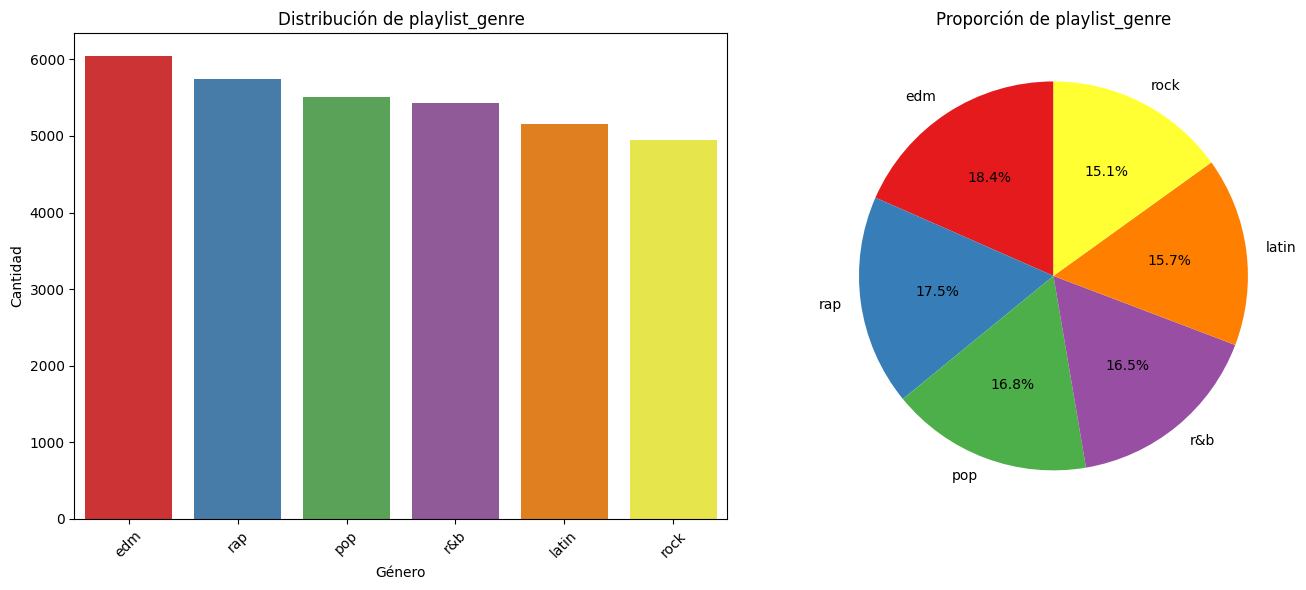

In [48]:
genre_counts = df["playlist_genre"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras
sns.barplot(x=genre_counts.index, y=genre_counts.values, ax=ax[0], palette="Set1")
ax[0].set_title("Distribución de playlist_genre")
ax[0].set_xlabel("Género")
ax[0].set_ylabel("Cantidad")
ax[0].tick_params(axis="x", rotation=45)

# Gráfico de pastel
ax[1].pie(
    genre_counts.values,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set1", len(genre_counts))
)
ax[1].set_title("Proporción de playlist_genre")

plt.tight_layout()
plt.show()

## **Análisis de correlación**

In [49]:
num_cols = df_model.select_dtypes(include=np.number).columns
corr = df_model[num_cols].corr()

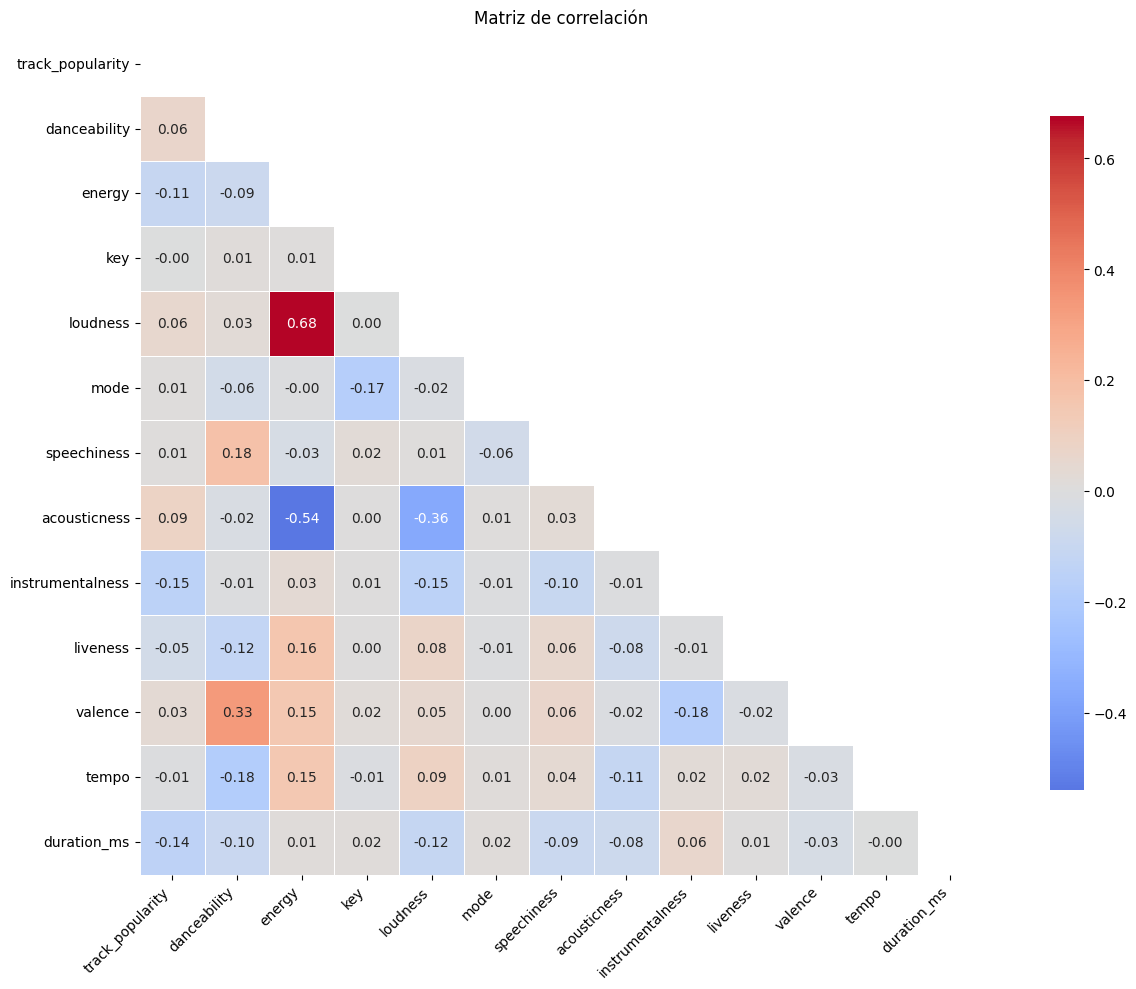

In [50]:
plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de correlación")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **Definir X e y**

In [51]:
X = df_model.drop(columns=["playlist_genre"])
y = df_model["playlist_genre"]

In [52]:
cols_modelo = [
    "track_popularity", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms", "playlist_genre"
]

df_model = df[cols_modelo].copy()
X = df_model.drop(columns=["playlist_genre"])
y = df_model["playlist_genre"]

## **Train, validation y test**

In [53]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

## **Ingeniería de características**
 - No se creó una transformación compleja.

- Se trabajó con variables originales.

- Se descartaron columnas de identificación y texto.

- Solo se mantuvieron variables útiles para clasificación.

- Se normalizaron variables numéricas en el pipeline.



## **Preparación del mejor modelo**

El mejor modelo fue Gradient Boosting con estos hiperparámetros:

- n_estimators = 200

- learning_rate = 0.1

- max_depth = 4

- min_samples_split = 2

- random_state = 42

In [54]:
gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=2,
        random_state=42
    ))
])

In [55]:
print(X.select_dtypes(exclude=["number"]).columns)

Index([], dtype='str')


## **Entrenar**

In [56]:
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [63]:
from pathlib import Path
import os
import joblib

project_root = Path.cwd().parent
models_dir = project_root / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(gb_pipeline, models_dir / "gb_pipeline.pkl")

['c:\\Users\\bolis\\Downloads\\Ml\\spotify-genre-project\\models\\gb_pipeline.pkl']

In [64]:
model_test = joblib.load(project_root / "models" / "gb_pipeline.pkl")

## **Evaluar el modelo**

### **Predicción**

In [65]:
y_pred = gb_pipeline.predict(X_test)

In [66]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.5523
Precision: 0.5514
Recall:    0.5523
F1-score:  0.5511


### **Matriz de confusión**

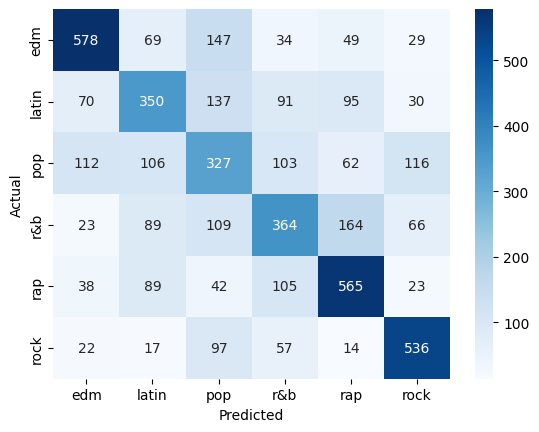

In [67]:
cm = confusion_matrix(y_test, y_pred, labels=gb_pipeline.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=gb_pipeline.classes_,
            yticklabels=gb_pipeline.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         edm       0.69      0.64      0.66       906
       latin       0.49      0.45      0.47       773
         pop       0.38      0.40      0.39       826
         r&b       0.48      0.45      0.46       815
         rap       0.60      0.66      0.62       862
        rock       0.67      0.72      0.69       743

    accuracy                           0.55      4925
   macro avg       0.55      0.55      0.55      4925
weighted avg       0.55      0.55      0.55      4925



In [69]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

In [70]:
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

print("RF accuracy:", accuracy_score(y_test, rf_pred))
print("RF precision:", precision_score(y_test, rf_pred, average="weighted"))
print("RF recall:", recall_score(y_test, rf_pred, average="weighted"))
print("RF f1:", f1_score(y_test, rf_pred, average="weighted"))

RF accuracy: 0.5472081218274112
RF precision: 0.5402764934474649
RF recall: 0.5472081218274112
RF f1: 0.5417576373429577


## **PyCaret**
PyCaret te permite comparar modelos con menos código.